# RPS PreTrained YOLO Fine-tuning

## g-drive 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Mounted at /content/drive
g-drive mounted.


## 경로 설정

In [ ]:
if colab:
    # 코랩(Colab) 환경일 때의 경로 (은수님의 실제 구글 드라이브 폴더명 반영)
    save_dir = '/content/drive/MyDrive/AI_COLAB_examples/save/'
    dataset_zip = '/content/drive/MyDrive/AI_COLAB_examples/Obstacle_Dataset.zip'
    dataset_root = '/content/Obstacle_Dataset'
    project_root = '/content/drive/MyDrive/AI_COLAB_examples/runs'
else:
    # 로컬(PC) 환경일 때의 경로
    save_dir = '../save/'
    dataset_zip = '../Obstacle_Dataset.zip'
    dataset_root = './Obstacle_Dataset'
    project_root = './runs'

## RPS 데이터셋 준비

In [ ]:
!unzip -q -o {dataset_zip} -d {dataset_root}

## RPS 데이터셋의 Label 만들기

In [ ]:
import json, os

CLASSES = [
    'StreetTreeCover',
    'SignalPole',
    'PublicToilet',
    'Manhole',
    'Bollard',
    'StationShelter',
]

def coco_bbox_to_yolo(img_w, img_h, bbox):
    """COCO bbox [x_min, y_min, width, height] -> YOLO [cx, cy, w, h] (정규화)."""
    x, y, w, h = bbox
    cx = (x + w / 2.0) / img_w
    cy = (y + h / 2.0) / img_h
    nw = w / img_w
    nh = h / img_h

    cx = min(max(cx, 0.0), 1.0)
    cy = min(max(cy, 0.0), 1.0)
    nw = min(nw, 1.0)
    nh = min(nh, 1.0)
    return cx, cy, nw, nh

train_img_dir   = os.path.join(dataset_root, 'images/train')
train_label_dir = os.path.join(dataset_root, 'labels/train')
os.makedirs(train_label_dir, exist_ok=True)

class_counts = {c: 0 for c in CLASSES}

json_files = [f for f in os.listdir(train_img_dir) if f.lower().endswith('.json')]
for filename in json_files:
    with open(os.path.join(train_img_dir, filename), 'r', encoding='utf-8') as f:
        data = json.load(f)

    img_map = {
        img['id']: (float(img['width']), float(img['height']), img['file_name'])
        for img in data.get('images', [])
    }
    if not img_map:
        continue

    lines_by_image = {iid: [] for iid in img_map}

    for ann in data.get('annotations', []):
        iid = ann.get('image_id')
        if iid not in img_map:
            continue
        cls = ann.get('attributes', {}).get('class')
        if cls not in CLASSES:
            continue
        if 'bbox' not in ann:
            continue

        img_w, img_h, _ = img_map[iid]
        cls_id = CLASSES.index(cls)
        cx, cy, nw, nh = coco_bbox_to_yolo(img_w, img_h, ann['bbox'])
        lines_by_image[iid].append(f"{cls_id} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
        class_counts[cls] += 1

    for iid, (_, _, file_name) in img_map.items():
        base = os.path.splitext(file_name)[0]
        out_file = os.path.join(train_label_dir, base + '.txt')
        with open(out_file, 'w') as out_f:
            if lines_by_image[iid]:
                out_f.write("\n".join(lines_by_image[iid]) + "\n")

print(f"JSON -> TXT 변환 완료: 총 {len(json_files)}개 JSON 처리")
print("클래스별 객체 수:")
for c in CLASSES:
    print(f"  {c}: {class_counts[c]}")

JSON -> TXT 변환 완료: 총 600개 JSON 처리
클래스별 객체 수:
  StreetTreeCover: 100
  SignalPole: 100
  PublicToilet: 100
  Manhole: 100
  Bollard: 165
  StationShelter: 100


In [ ]:
import os, random, shutil

train_img_dir   = os.path.join(dataset_root, 'images/train')
train_label_dir = os.path.join(dataset_root, 'labels/train')
val_img_dir     = os.path.join(dataset_root, 'images/val')
val_label_dir   = os.path.join(dataset_root, 'labels/val')
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_label_dir, exist_ok=True)

all_images = [f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print("이미지 파일 개수(json 제외):", len(all_images))

random.seed(42)
val_size = max(1, int(len(all_images) * 0.2))
val_images = random.sample(all_images, val_size)

moved_img = moved_label = 0
for img in val_images:
    shutil.move(os.path.join(train_img_dir, img), os.path.join(val_img_dir, img))
    moved_img += 1
    txt_file = os.path.splitext(img)[0] + '.txt'
    src_label = os.path.join(train_label_dir, txt_file)
    if os.path.exists(src_label):
        shutil.move(src_label, os.path.join(val_label_dir, txt_file))
        moved_label += 1

print(f"이미지 이동: {moved_img}개, 라벨 이동: {moved_label}개")
print("val 폴더 최종 이미지 수:", len(os.listdir(val_img_dir)))

이미지 파일 개수(json 제외): 600
이미지 이동: 120개, 라벨 이동: 120개
val 폴더 최종 이미지 수: 120


In [ ]:
import yaml

data = {
    'train': os.path.join(dataset_root, 'images/train'),
    'val':   os.path.join(dataset_root, 'images/val'),
    'nc':    len(CLASSES),
    'names': CLASSES,
}
yaml_path = os.path.join(dataset_root, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print("data.yaml 생성:", yaml_path)
print(data)

data.yaml 생성: /content/Obstacle_Dataset/data.yaml
{'train': '/content/Obstacle_Dataset/images/train', 'val': '/content/Obstacle_Dataset/images/val', 'nc': 6, 'names': ['StreetTreeCover', 'SignalPole', 'PublicToilet', 'Manhole', 'Bollard', 'StationShelter']}


## Ultralytics 설치 및 import

In [ ]:
!pip -q install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 학습

In [ ]:
yolo = YOLO('yolo11n.pt')

In [ ]:
new_root = dataset_root

In [ ]:
import os

val_label_dir = os.path.join(new_root, 'labels/val')
bad_boxes = []
all_boxes = []

for fname in os.listdir(val_label_dir):
    path = os.path.join(val_label_dir, fname)
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            cid, cx, cy, w, h = parts[0], *map(float, parts[1:])
            all_boxes.append((cid, cx, cy, w, h))
            if w <= 0.001 or h <= 0.001 or cx < 0 or cx > 1 or cy < 0 or cy > 1:
                bad_boxes.append((fname, cid, cx, cy, w, h))

print("전체 box 수:", len(all_boxes))
print("이상한 box 수:", len(bad_boxes))
print("이상 box 샘플:", bad_boxes[:10])

ws = [b[3] for b in all_boxes]
hs = [b[4] for b in all_boxes]
print(f"\nw 최소/최대/평균: {min(ws):.4f} / {max(ws):.4f} / {sum(ws)/len(ws):.4f}")
print(f"h 최소/최대/평균: {min(hs):.4f} / {max(hs):.4f} / {sum(hs)/len(hs):.4f}")

전체 box 수: 135
이상한 box 수: 0
이상 box 샘플: []

w 최소/최대/평균: 0.0320 / 1.0000 / 0.4881
h 최소/최대/평균: 0.0761 / 1.0000 / 0.4973


In [ ]:
DATA = f'{new_root}/data.yaml'

yolo = YOLO('yolo11n.pt')
yolo.train(data=DATA, epochs=80, batch=16,
            imgsz=640, device=0, workers=4,
            project=project_root,
            degrees=15.0, flipud=0.0, fliplr=0.5, mosaic=1.0,
            name='obstacle_v2')

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


KeyboardInterrupt: 

In [ ]:
import os

train_img_dir = os.path.join(dataset_root, 'images/train')
val_img_dir = os.path.join(dataset_root, 'images/val')

print("train 폴더 파일 수:", len(os.listdir(train_img_dir)))
print("train 폴더 샘플 파일명 5개:", os.listdir(train_img_dir)[:5])
print("val 폴더 파일 수:", len(os.listdir(val_img_dir)))

In [ ]:
import os

print("project_root 경로:", project_root)
print("존재 여부:", os.path.exists(project_root))

if os.path.exists(project_root):
    print("\n하위 폴더 목록:")
    for item in os.listdir(project_root):
        print(" -", item)

print("\nbest.pt 검색 결과:")
for root, dirs, files in os.walk(project_root):
    for file in files:
        if file == 'best.pt':
            print(" 찾음:", os.path.join(root, file))

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


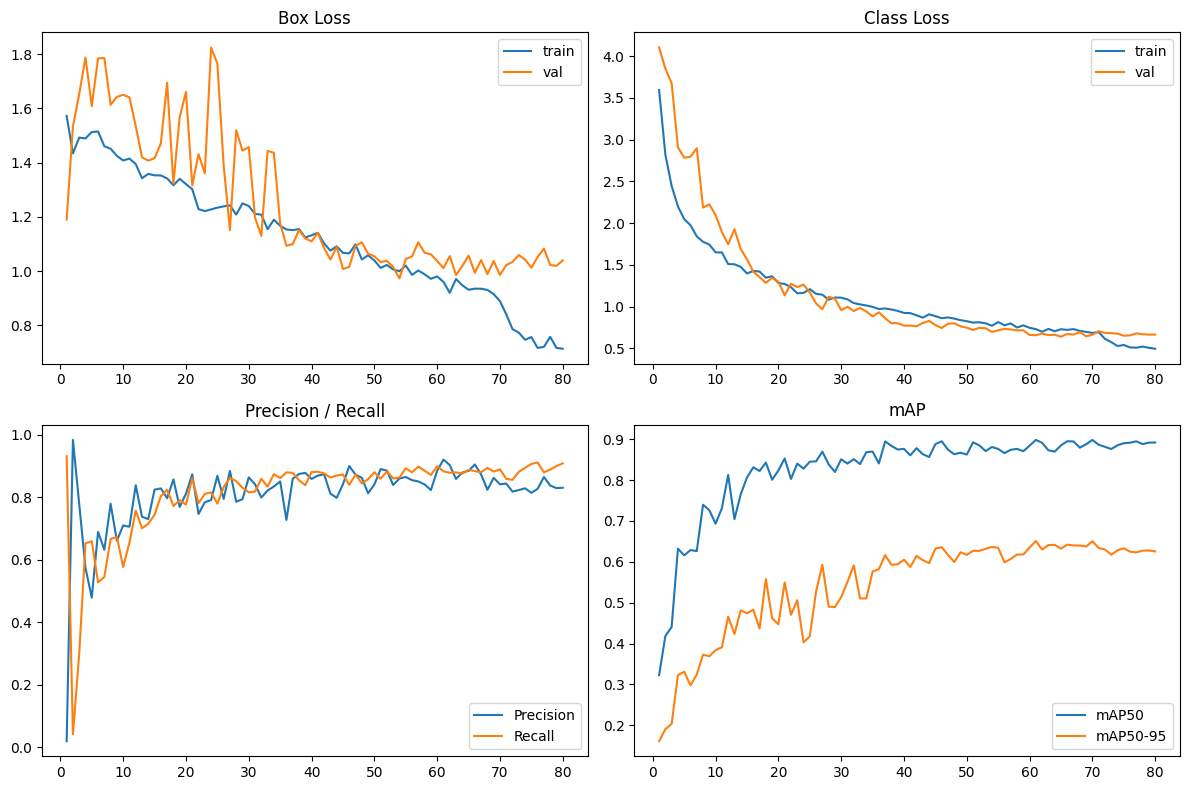

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = os.path.join(project_root, 'obstacle_v1', 'results.csv')
df = pd.read_csv(results_path)
df.columns = [c.strip() for c in df.columns]
print(df.columns.tolist())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='train')
axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='val')
axes[0, 0].set_title('Box Loss'); axes[0, 0].legend()

axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='train')
axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='val')
axes[0, 1].set_title('Class Loss'); axes[0, 1].legend()

axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
axes[1, 0].set_title('Precision / Recall'); axes[1, 0].legend()

axes[1, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
axes[1, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
axes[1, 1].set_title('mAP'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'training_summary.png'))
plt.show()

## ONNX 모델로 변환

In [ ]:
BEST = f'{project_root}/obstacle_v1/weights/best.pt'

# model obejct instantiation w/ best.pt
yolo_best = YOLO(BEST)
# model export to onnx format
yolo_best.export(format='onnx',
                 imgsz=640,
                 #int8=True,
                 opset=18,
                 simplify=True)


## ONNX 파일 저장

In [ ]:
onnx_best = 'obstacle_v1.onnx'
save_file = f'{save_dir}/{onnx_best}'

In [ ]:
!cp {project_root}/obstacle_v1/weights/best.onnx {onnx_best}

In [ ]:
import os
os.makedirs(os.path.dirname(save_file), exist_ok=True)

!cp {onnx_best} {save_file}
print(f"파일이 성공적으로 복사되었습니다: {save_file}")

In [ ]:
from google.colab import files
files.download(onnx_best)